#**FINAL PROJECT DATA VISUALISASI**

# 0. Install Dependencies

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import plotly.express as px


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [ ]:
file_id = "1b6bgbWjpzhIjjsj0XGh4iRH4WOQFetZu"
url = f"https://drive.google.com/uc?id={file_id}"
output = "hrd.xlsx"
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1b6bgbWjpzhIjjsj0XGh4iRH4WOQFetZu
To: /content/hrd.xlsx
100%|██████████| 549k/549k [00:00<00:00, 41.0MB/s]


'hrd.xlsx'

# 1. Data Understanding

In [ ]:
df = pd.read_excel("hrd.xlsx")
df.head()

/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,PayRate,Termd,PositionID,Position,State,Zip,DOB,Sex,MaritalDesc,CitizenDesc,HispanicLatino,RaceDesc,DateofHire,DateofTermination,TermReason,EmploymentStatus,Department,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Original DS
0,"Gonzalez, Maria",1988299991,0,3,0,1,3,3,0,39.0,0,14,IT Support,MA,2472.0,1981-04-16,F,Separated,US Citizen,Yes,White,2015-01-05,NaT,N/A - still employed,Active,IT/IS,Peter Monroe,7.0,Employee Referral,Fully Meets,4.61,4,5,2019-01-28,0.0,Orig
1,"Cockel, James",1599991009,0,0,1,1,5,3,0,15.0,0,19,Production Technician I,MA,2452.0,1977-09-08,M,Single,US Citizen,No,White,2013-07-08,NaT,N/A - still employed,Active,Production,David Stanley,14.0,Employee Referral,Fully Meets,1.51,5,0,2019-01-14,0.0,Orig
2,"Bunbury, Jessica",1504073368,1,1,0,5,6,3,0,55.0,1,3,Area Sales Manager,VA,21851.0,1964-06-01,F,Married,Eligible NonCitizen,No,Black or African American,2011-08-15,2014-08-02,Another position,Voluntarily Terminated,Sales,John Smith,17.0,Social Networks - Facebook Twitter etc,Fully Meets,3.14,5,0,NaT,NaN,Orig
3,"Buck, Edward",1504073313,1,1,1,1,6,3,0,55.0,0,3,Area Sales Manager,MA,2330.0,1975-07-07,M,Married,US Citizen,No,White,2014-09-29,NaT,N/A - still employed,Active,Sales,Lynn Daneault,21.0,Employee Referral,Fully Meets,3.31,5,0,2019-01-28,0.0,Orig
4,"Jacobi, Hannah",1503072857,0,2,0,1,5,3,0,21.0,0,19,Production Technician I,MA,1778.0,1966-03-22,F,Divorced,US Citizen,No,White,2013-09-30,NaT,N/A - still employed,Active,Production,Kissy Sullivan,20.0,Employee Referral,Fully Meets,2.05,5,0,2019-02-22,0.0,Orig


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3310 entries, 0 to 3309
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Employee_Name               3310 non-null   object        
 1   EmpID                       3310 non-null   int64         
 2   MarriedID                   3310 non-null   int64         
 3   MaritalStatusID             3310 non-null   int64         
 4   GenderID                    3310 non-null   int64         
 5   EmpStatusID                 3310 non-null   int64         
 6   DeptID                      3310 non-null   int64         
 7   PerfScoreID                 3310 non-null   int64         
 8   FromDiversityJobFairID      3310 non-null   int64         
 9   PayRate                     3310 non-null   float64       
 10  Termd                       3310 non-null   int64         
 11  PositionID                  3310 non-null   int64       

> Tipe data sudah sesuai

**Variabel:**
- `Employee_Name`: Nama lengkap karyawan.
- `EmpID`: Nomor identitas unik karyawan.
- `MarriedID`: Kode status pernikahan karyawan (0 = belum menikah, 1 = menikah).
- `MaritalStatusID`: Kode numerik yang mewakili status pernikahan.
- `GenderID`: Kode numerik jenis kelamin karyawan.
- `EmpStatusID`: Kode status kepegawaian (aktif, kontrak, keluar, dll).
- `DeptID`: Kode numerik departemen tempat karyawan bekerja.
- `PerfScoreID`: Kode numerik tingkat penilaian kinerja karyawan.
- `FromDiversityJobFairID`: Indikator apakah karyawan direkrut dari acara job fair.
- `PayRate`: Tingkat gaji atau upah per jam karyawan.
- `Termd`: Indikator apakah karyawan sudah diberhentikan (1) atau masih aktif (0).
- `PositionID`: Kode numerik jabatan atau posisi karyawan.
- `Position`: Nama jabatan atau posisi karyawan.
- `State`: Negara bagian atau wilayah tempat karyawan bekerja.
- `Zip`: Kode pos area tempat karyawan bekerja.
- `DOB`: Tanggal lahir karyawan.
- `Sex`: Jenis kelamin karyawan.
- `MaritalDesc`: Deskripsi status pernikahan (Menikah, Lajang, Duda/Janda, dll).
- `CitizenDesc`: Status kewarganegaraan karyawan.
- `HispanicLatino`: Indikator apakah karyawan keturunan Hispanik atau Latin.
- `RaceDesc`: Deskripsi ras atau etnis karyawan.
- `DateofHire`: Tanggal karyawan mulai bekerja di perusahaan.
- `DateofTermination`: Tanggal karyawan berhenti atau diberhentikan.
- `TermReason`: Alasan karyawan keluar dari perusahaan.
- `EmploymentStatus`: Status kerja karyawan saat ini.
- `Department`: Nama departemen tempat karyawan bekerja.
- `ManagerName`: Nama atasan langsung (manajer) karyawan.
- `ManagerID`: Kode identitas manajer karyawan.
- `RecruitmentSource`: Sumber rekrutmen tempat karyawan direkrut.
- `PerformanceScore`: Penilaian kinerja karyawan.
- `EngagementSurvey`: Skor survei keterlibatan karyawan terhadap perusahaan.
- `EmpSatisfaction`: Tingkat kepuasan karyawan terhadap pekerjaan.
-  `SpecialProjectsCount`: Jumlah proyek khusus yang dikerjakan oleh karyawan.
- `LastPerformanceReview_Date`: Tanggal terakhir evaluasi kinerja dilakukan.
- `DaysLateLast30`: Jumlah hari keterlambatan karyawan dalam 30 hari terakhir.
- `Original DS`: Catatan sumber data atau tanggal pencatatan asli karyawan.

In [ ]:
df.shape

(3310, 36)

#2. Data Preparation

In [ ]:
df_prep = df.copy()

## 2.1 Data Selection

In [ ]:
# Seleksi kolom relevan
selected_columns = [
    'EmpID', 'Employee_Name', 'DOB', 'Sex', 'MaritalDesc',
    'RaceDesc', 'State', 'Zip', 'DateofHire', 'DateofTermination',
    'TermReason', 'EmploymentStatus','Department', 'Position', 'ManagerName',
    'PayRate', 'PerformanceScore', 'EngagementSurvey',
    'EmpSatisfaction', 'SpecialProjectsCount'
]

df_prep = df_prep[selected_columns].copy()
df_prep.head()

,EmpID,Employee_Name,DOB,Sex,MaritalDesc,RaceDesc,State,Zip,DateofHire,DateofTermination,TermReason,EmploymentStatus,Department,Position,ManagerName,PayRate,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount
0,1988299991,"Gonzalez, Maria",1981-04-16,F,Separated,White,MA,2472.0,2015-01-05,NaT,N/A - still employed,Active,IT/IS,IT Support,Peter Monroe,39.0,Fully Meets,4.61,4,5
1,1599991009,"Cockel, James",1977-09-08,M,Single,White,MA,2452.0,2013-07-08,NaT,N/A - still employed,Active,Production,Production Technician I,David Stanley,15.0,Fully Meets,1.51,5,0
2,1504073368,"Bunbury, Jessica",1964-06-01,F,Married,Black or African American,VA,21851.0,2011-08-15,2014-08-02,Another position,Voluntarily Terminated,Sales,Area Sales Manager,John Smith,55.0,Fully Meets,3.14,5,0
3,1504073313,"Buck, Edward",1975-07-07,M,Married,White,MA,2330.0,2014-09-29,NaT,N/A - still employed,Active,Sales,Area Sales Manager,Lynn Daneault,55.0,Fully Meets,3.31,5,0
4,1503072857,"Jacobi, Hannah",1966-03-22,F,Divorced,White,MA,1778.0,2013-09-30,NaT,N/A - still employed,Active,Production,Production Technician I,Kissy Sullivan,21.0,Fully Meets,2.05,5,0


- Variabel dipilih untuk mencakup identitas, demografi, status kerja, struktur organisasi, lokasi, dan kinerja karyawan.
- Variabel seperti EmpID, Employee_Name, DOB, Sex, MaritalDesc, CitizenDesc, HispanicLatino, RaceDesc, State, dan Zip membantu identifikasi profil tenaga kerja
- Variabel DateofHire, DateofTermination, TermReason, EmploymentStatus, Department, Position, ManagerName, PayRate, PerformanceScore, EngagementSurvey, EmpSatisfaction, dan SpecialProjectsCount mendukung analisis masa kerja, struktur organisasi, kinerja, dan keterlibatan karyawan.
- Variabel duplikatif seperti Termd, HispanicLatino, dan ID numerik (misal ManagerID, DeptID, dll.) dihapus karena informasi mereka sudah tercakup dalam kolom deskriptif.
- Variabel lain yang kurang relevan seperti CitizenDesc, RecruitmentSource, LastPerformanceReview_Date, DaysLateLast30, dan Original DS juga dihapus agar dataset lebih fokus untuk analisis.

##2.2 Duplicate Data

In [ ]:
df_prep.duplicated().sum()

np.int64(0)

> Tidak ada duplikasi data, tidak perlu ditangani

## 2.3 Missing Values

In [ ]:
# Cek jumlah missing value
missing_count = df_prep.isna().sum()
missing_percent = round(((missing_count / len(df_prep)) * 100),2)

missing_df = pd.DataFrame({
    'MissingCount': missing_count,
    'MissingPercent': missing_percent
}).sort_values(by='MissingPercent', ascending=False)

missing_df

,MissingCount,MissingPercent
Zip,3000,90.63
DateofTermination,2351,71.03
ManagerName,78,2.36
TermReason,11,0.33
Sex,0,0.00
DOB,0,0.00
Employee_Name,0,0.00
EmpID,0,0.00
State,0,0.00
RaceDesc,0,0.00


> Variabel yang memiliki missing value antara lain DateofTermination, TermReason, ManagerName, dan ManagerID. Kolom DateofTermination kosong karena karyawan masih aktif, TermReason kosong akibat data administrasi tidak tercatat, sedangkan ManagerName dan ManagerID kosong karena beberapa karyawan berada di posisi top management atau data manajer belum tercatat dalam sistem.

In [ ]:
# 1. Hapus kolom Zip karena tidak relevan untuk analisis HR
df_prep.drop(columns=['Zip'], inplace=True)

# 2. Isi missing pada TermReason dengan 'Unknown'
df_prep['TermReason'] = df_prep['TermReason'].fillna('Unknown')

# 3. Penanganan terhadap kolom ManagerName (top-level)
df_prep['ManagerName'] = df_prep['ManagerName'].fillna('No Manager')

missing_after = df_prep.isna().sum()
print(missing_after[missing_after > 0])

DateofTermination    2351
dtype: int64


- Variabel `Zip` di hapus karena sebagai besar merupakan missing value dan tidak terlalu relevan untuk digunakan.
- Variabel `TermReason` diisi dengan nilai 'Unknown' yang artinya tidak diketahui alasan berhenti bekerja.
- Variabel `ManagerName` diisi dengan 'No Manager' untuk menunjukkan karyawan top-level tanpa atasan langsung.
- Variabel `DateofTermination` dibiarkan kosong (NaT) karena merepresentasikan karyawan yang masih aktif bekerja, sehingga tidak dianggap sebagai data hilang.

## 2.4 Outlier

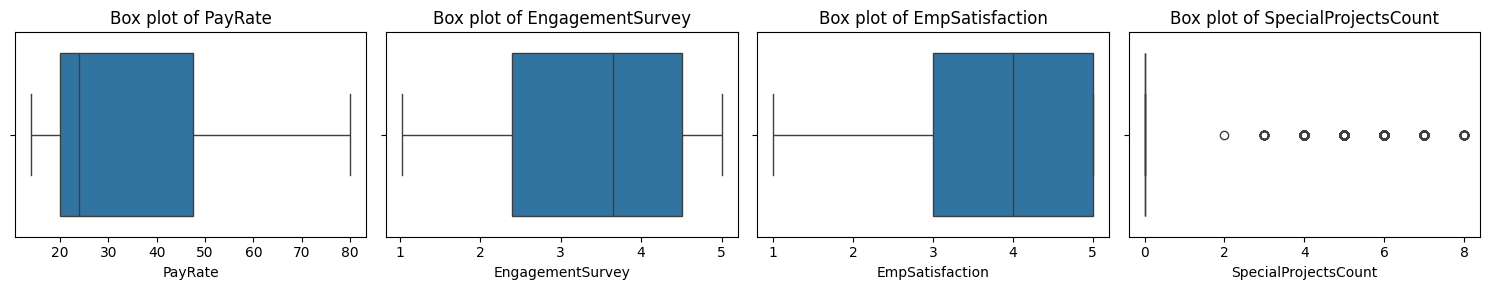

In [ ]:
df_outlier = df_prep.drop(['EmpID'], axis=1)
numerical_cols = df_outlier.select_dtypes(include='number').columns
plt.figure(figsize=(15, 3))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, 4, i + 1)
    sns.boxplot(x=df_prep[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

> Pada tahap ini, Outlier tidak dilakukan penanganan dikarenakan data sudah merepresentasikan data kenyataaan

## 2.5 Data Transformation

In [ ]:
for col in df_prep.columns:
    uniques = df_prep[col].unique()
    print(f"Column: {col} ({len(uniques)} unique values)")
    print(uniques)
    print("-" * 40)

Column: EmpID (3310 unique values)
[1988299991 1599991009 1504073368 ... 9034760003 9005990002 9011850001]
----------------------------------------
Column: Employee_Name (3308 unique values)
['Gonzalez, Maria' 'Cockel, James' 'Bunbury, Jessica' ... 'Braun, Jacey'
 'Kline, Nathan' 'Benitez, Gabriella']
----------------------------------------
Column: DOB (306 unique values)
<DatetimeArray>
['1981-04-16 00:00:00', '1977-09-08 00:00:00', '1964-06-01 00:00:00',
 '1975-07-07 00:00:00', '1966-03-22 00:00:00', '1968-01-15 00:00:00',
 '1955-04-14 00:00:00', '1968-10-10 00:00:00', '1990-10-01 00:00:00',
 '1990-05-11 00:00:00',
 ...
 '1983-02-09 00:00:00', '1970-10-08 00:00:00', '1982-05-19 00:00:00',
 '1970-02-08 00:00:00', '1975-03-10 00:00:00', '1986-06-10 00:00:00',
 '1974-12-05 00:00:00', '1973-12-08 00:00:00', '1982-11-15 00:00:00',
 '1988-10-05 00:00:00']
Length: 306, dtype: datetime64[ns]
----------------------------------------
Column: Sex (2 unique values)
['F' 'M']
-------------------

In [ ]:
# Transformasi kolom 'Sex'
df_prep['Sex'] = df_prep['Sex'].replace({'M': 'Male', 'F': 'Female'})

# Transformasi kolom 'Employee_Name' (mengubah format "Lastname, Firstname" menjadi "Firstname Lastname")
df_prep['Employee_Name'] = df_prep['Employee_Name'].apply(lambda x: ' '.join(x.split(', ')[::-1]))

# Transformasi kolom 'PerformanceScore' menjadi nilai numerik (sesuai urutan kinerja)
performance_mapping = {
    'Needs Improvement': 1,
    'PIP': 2,
    'Fully Meets': 3,
    'Exceeds': 4
}
df_prep['PerformanceScore'] = df_prep['PerformanceScore'].map(performance_mapping)

# Transformasi kolom 'State' (mengubah singkatan menjadi nama lengkap)
state_mapping = {
    'MA': 'Massachusetts', 'VA': 'Virginia', 'ND': 'North Dakota', 'FL': 'Florida',
    'CT': 'Connecticut', 'UT': 'Utah', 'ID': 'Idaho', 'MT': 'Montana',
    'CA': 'California', 'WA': 'Washington', 'TX': 'Texas', 'VT': 'Vermont',
    'OR': 'Oregon', 'AZ': 'Arizona', 'NH': 'New Hampshire', 'AL': 'Alabama',
    'OH': 'Ohio', 'NY': 'New York', 'IN': 'Indiana', 'GA': 'Georgia',
    'ME': 'Maine', 'PA': 'Pennsylvania', 'CO': 'Colorado', 'KY': 'Kentucky',
    'RI': 'Rhode Island', 'TN': 'Tennessee', 'NV': 'Nevada', 'NC': 'North Carolina'
}
df_prep['State'] = df_prep['State'].map(state_mapping)


print("Unique values in 'Sex' after transformation:")
print(df_prep['Sex'].unique())
print("-" * 30)
print("First 5 values in 'Employee_Name' after transformation:")
print(df_prep['Employee_Name'].head())
print("-" * 30)
print("Unique values in 'PerformanceScore' after transformation:")
print(df_prep['PerformanceScore'].unique())
print("-" * 30)
print("Unique values in 'State' after transformation:")
print(df_prep['State'].unique())

Unique values in 'Sex' after transformation:
['Female' 'Male']
------------------------------
First 5 values in 'Employee_Name' after transformation:
0     Maria Gonzalez
1       James Cockel
2    Jessica Bunbury
3        Edward Buck
4      Hannah Jacobi
Name: Employee_Name, dtype: object
------------------------------
Unique values in 'PerformanceScore' after transformation:
[3 4 2 1]
------------------------------
Unique values in 'State' after transformation:
['Massachusetts' 'Virginia' 'North Dakota' 'Florida' 'Connecticut' 'Utah'
 'Idaho' 'Montana' 'California' 'Washington' 'Texas' 'Vermont' 'Oregon'
 'Arizona' 'New Hampshire' 'Alabama' 'Ohio' 'New York' 'Indiana' 'Georgia'
 'Maine' 'Pennsylvania' 'Colorado' 'Kentucky' 'Rhode Island' 'Tennessee'
 'Nevada' 'North Carolina']


In [ ]:
df_prep.to_excel("Data_HR.xlsx", index=False)
print("DataFrame df_prep telah disimpan")

DataFrame df_prep telah disimpan


# 3. EDA

In [ ]:
df_eda = df_prep.drop('EmpID', axis=1)
display(df_eda.select_dtypes(include='number').describe())
display(df_eda.select_dtypes(include='object').describe())

,PayRate,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount
count,3310.000000,3310.000000,3310.000000,3310.000000,3310.000000
mean,31.843634,2.981571,3.378118,3.890937,1.177039
std,15.717917,0.607666,1.279116,0.831829,2.273280
min,14.000000,1.000000,1.030000,1.000000,0.000000
25%,20.000000,3.000000,2.390000,3.000000,0.000000
50%,24.000000,3.000000,3.650000,4.000000,0.000000
75%,47.600000,3.000000,4.510000,5.000000,0.000000
max,80.000000,4.000000,5.000000,5.000000,8.000000


,Employee_Name,Sex,MaritalDesc,RaceDesc,State,TermReason,EmploymentStatus,Department,Position,ManagerName
count,3310,3310,3310,3310,3310,3310,3310,3310,3310,3310
unique,3308,2,5,6,28,18,5,6,31,22
top,Darien Young,Female,Single,White,Massachusetts,N/A - still employed,Active,Production,Production Technician I,Elijiah Gray
freq,2,1858,1392,2178,2943,2212,1984,2231,1482,255


# 4. Visualisasi

In [ ]:
df = df_prep.copy()
display(df.head())
display(df.shape)

,EmpID,Employee_Name,DOB,Sex,MaritalDesc,RaceDesc,State,DateofHire,DateofTermination,TermReason,EmploymentStatus,Department,Position,ManagerName,PayRate,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount
0,1988299991,Maria Gonzalez,1981-04-16,Female,Separated,White,Massachusetts,2015-01-05,NaT,N/A - still employed,Active,IT/IS,IT Support,Peter Monroe,39.0,3,4.61,4,5
1,1599991009,James Cockel,1977-09-08,Male,Single,White,Massachusetts,2013-07-08,NaT,N/A - still employed,Active,Production,Production Technician I,David Stanley,15.0,3,1.51,5,0
2,1504073368,Jessica Bunbury,1964-06-01,Female,Married,Black or African American,Virginia,2011-08-15,2014-08-02,Another position,Voluntarily Terminated,Sales,Area Sales Manager,John Smith,55.0,3,3.14,5,0
3,1504073313,Edward Buck,1975-07-07,Male,Married,White,Massachusetts,2014-09-29,NaT,N/A - still employed,Active,Sales,Area Sales Manager,Lynn Daneault,55.0,3,3.31,5,0
4,1503072857,Hannah Jacobi,1966-03-22,Female,Divorced,White,Massachusetts,2013-09-30,NaT,N/A - still employed,Active,Production,Production Technician I,Kissy Sullivan,21.0,3,2.05,5,0


(3310, 19)

In [ ]:
df["HireYear"] = df["DateofHire"].dt.year
df["TermYear"] = df["DateofTermination"].dt.year.astype("Int64")

current_year = df['DateofTermination'].dt.year.max()

## 4.1 Berapa nilai 5 KPI utama yang mencerminkan kondisi tenaga kerja saat ini?

In [ ]:
# 1. Total employee aktif
active_employees = df[df['EmploymentStatus'] == 'Active'].shape[0]

# 2. Total karyawan keluar
terminated_this_year = df[df["DateofTermination"].dt.year == current_year].shape[0]

# 3. Turnover rate
# Turnover Rate (%) = (Karyawan Keluar di tahun Y / Karyawan Aktif Awal tahun Y) x 100
years = sorted(pd.concat([df["HireYear"], df["TermYear"]], ignore_index=True).dropna().astype(int).unique())
turnover_df = pd.DataFrame({"Tahun": years})
turnover_df["Karyawan Keluar"] = turnover_df["Tahun"].apply(lambda y: (df["TermYear"] == y).sum())
turnover_df["Karyawan Aktif Awal"] = turnover_df["Tahun"].apply(lambda y: len(df[(df["HireYear"] <= y) & ((df["TermYear"].isna()) | (df["TermYear"] >= y))]))
turnover_df["Turnover Rate (%)"] = round(turnover_df["Karyawan Keluar"] / turnover_df["Karyawan Aktif Awal"] * 100, 2)
current_year = turnover_df["Tahun"].max()
turnover_current_year = turnover_df.loc[turnover_df["Tahun"] == current_year, "Turnover Rate (%)"].values[0]

# 4. Rata-rata masa kerja (tenure)
# dibagi 365.25 (mempertimbangkan kabisat)
tenure_list = []
for y in years:
    aktif = df[(df["HireYear"] <= y) & ((df["TermYear"].isna()) | (df["TermYear"] >= y))].copy()
    aktif["TenureYears"] = aktif.apply(lambda row: ((min(pd.Timestamp(year=y, month=12, day=31),row["DateofTermination"]
                                                         if pd.notna(row["DateofTermination"])
                                                         else pd.Timestamp(year=y, month=12, day=31)) - row["DateofHire"]).days) / 365.25,axis=1)
    avg_tenure = round(aktif["TenureYears"].mean(), 2) if not aktif.empty else 0
    tenure_list.append([y, avg_tenure])
tenure_df = pd.DataFrame(tenure_list, columns=["Tahun", "Rata-rata Tenure (tahun)"])
current_year = tenure_df["Tahun"].max()
tenure_current_year = tenure_df.loc[tenure_df["Tahun"] == current_year, "Rata-rata Tenure (tahun)"].values[0]

# 5. Rata-rata gaji bulanan (salary)
# monthly pay (40 jam/minggu × 4 minggu)
df["MonthlyPay"] = df["PayRate"] * 160

monthly_pay_list = []
for y in years:
    aktif = df[(df["HireYear"] <= y) & ((df["TermYear"].isna()) | (df["TermYear"] >= y))]
    avg_pay = round(aktif["MonthlyPay"].mean(), 2) if not aktif.empty else 0
    monthly_pay_list.append([y, avg_pay])
monthly_pay_df = pd.DataFrame(monthly_pay_list, columns=["Tahun", "Rata-rata Monthly Pay"])
current_year = monthly_pay_df["Tahun"].max()
monthly_pay_current_year = monthly_pay_df.loc[monthly_pay_df["Tahun"] == current_year, "Rata-rata Monthly Pay"].values[0]

print("Total Active Employees:", active_employees)
print("Total Terminated Employees:", terminated_this_year)
print("Turnover Rate (%):", round(turnover_current_year, 4))
print("Average Tenure (years):", round(tenure_current_year, 2))
print("Average Monthly Pay:", round(monthly_pay_current_year, 2))

Total Active Employees: 1984
Total Terminated Employees: 32
Turnover Rate (%): 1.34
Average Tenure (years): 5.69
Average Monthly Pay: 5400.69


## 4.2 Bagaimana tren tahunan dari kelima KPI tersebut?

In [ ]:
df["DateofHire"] = pd.to_datetime(df["DateofHire"], errors="coerce")
df["DateofTermination"] = pd.to_datetime(df["DateofTermination"], errors="coerce")
df["HireYear"] = df["DateofHire"].dt.year
df["TermYear"] = df["DateofTermination"].dt.year

# Tenure (tahun)
df["TenureYears"] = np.where(
    df["DateofTermination"].notna(),
    (df["DateofTermination"] - df["DateofHire"]).dt.days / 365.25,
    (pd.to_datetime("today") - df["DateofHire"]).dt.days / 365.25
)

# Monthly Pay
df["PayRate"] = df["PayRate"].fillna(0)
df["MonthlyPay"] = df["PayRate"] * 160

years = sorted(pd.concat([df["HireYear"], df["TermYear"]], ignore_index=True).dropna().astype(int).unique())
def calc_kpi(df, year):
    active = df[(df["HireYear"] <= year) & ((df["TermYear"].isna()) | (df["TermYear"] >= year))]
    left = df[df["TermYear"] == year]

    turnover_rate = (len(left) / len(active) * 100) if len(active) > 0 else 0
    avg_tenure = active.apply(lambda row: ((min(pd.Timestamp(year=year, month=12, day=31),
                                                row["DateofTermination"] if pd.notna(row["DateofTermination"]) else pd.Timestamp(year=year, month=12, day=31))
                                         - row["DateofHire"]).days) / 365.25, axis=1).mean() if not active.empty else 0
    avg_salary = active["MonthlyPay"].mean() if not active.empty else 0

    return {
        "Year": year,
        "Left": len(left),
        "TurnoverRate": round(turnover_rate, 2),
        "AvgTenure": round(avg_tenure, 2),
        "AvgMonthlyPay": round(avg_salary, 2)
    }

kpi_trends = [calc_kpi(df, y) for y in years]
kpi_df = pd.DataFrame(kpi_trends)

active_per_year = pd.DataFrame({"Year": years})
active_per_year["Active"] = active_per_year["Year"].apply(
    lambda y: df[(df["EmploymentStatus"] == "Active") & (df["HireYear"] <= y)].shape[0]
)

CHART_WIDTH = 900
CHART_HEIGHT = 450
def center_title(fig):
    fig.update_layout(
        title_x=0.5,
        width=CHART_WIDTH,
        height=CHART_HEIGHT,
        template="plotly_white",
        margin=dict(t=50, l=30, r=30, b=30)
    )
    return fig

# 1. Jumlah Karyawan Aktif
fig1 = px.line(active_per_year, x="Year", y="Active", markers=True, title="Tren Jumlah Karyawan Aktif per Tahun")
center_title(fig1).show()

# 2. Jumlah Karyawan Keluar
fig2 = px.line(kpi_df, x="Year", y="Left", markers=True, title="Tren Jumlah Karyawan Keluar per Tahun")
center_title(fig2).show()

# 3. Turnover Rate
fig3 = px.line(kpi_df, x="Year", y="TurnoverRate", markers=True, title="Tren Turnover Rate per Tahun")
center_title(fig3).show()

# 4. Rata-rata Tenure
fig4 = px.line(kpi_df, x="Year", y="AvgTenure", markers=True, title="Tren Rata-rata Tenure Karyawan per Tahun")
center_title(fig4).show()

# 5. Rata-rata Monthly Pay
fig5 = px.line(kpi_df, x="Year", y="AvgMonthlyPay", markers=True, title="Tren Rata-rata Monthly Pay per Tahun")
center_title(fig5).show()

## 4.3 Bagaimana tren hiring dan turnover karyawan secara bulanan?

In [ ]:
import pandas as pd
import plotly.graph_objects as go

df["JoinDate"] = pd.to_datetime(df["DateofHire"], errors="coerce")
df["TermDate"] = pd.to_datetime(df["DateofTermination"], errors="coerce")

hiring_df = df[df["JoinDate"].notna()].assign(EventDate=lambda x: x["JoinDate"], Metric="Hiring")
term_df   = df[df["TermDate"].notna()].assign(EventDate=lambda x: x["TermDate"], Metric="Turnover")

combined_df = pd.concat([hiring_df, term_df], ignore_index=True)
combined_df["Period"] = combined_df["EventDate"].dt.to_period("M")
combined_df["Period_Date"] = combined_df["Period"].dt.to_timestamp()

monthly_df = (
    combined_df.groupby(["Period_Date", "Metric"])
    .size()
    .reset_index(name="Count")
    .pivot(index="Period_Date", columns="Metric", values="Count")
    .fillna(0)
    .reset_index()
)

# Ambil titik max
max_hire_y = monthly_df["Hiring"].max()
max_hire_x = monthly_df.loc[monthly_df["Hiring"].idxmax(), "Period_Date"]

max_term_y = monthly_df["Turnover"].max()
max_term_x = monthly_df.loc[monthly_df["Turnover"].idxmax(), "Period_Date"]

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_df["Period_Date"],
    y=monthly_df["Hiring"],
    mode="lines",
    name="Hiring",
    line=dict(width=3, color="#27AE60")
))

fig.add_trace(go.Scatter(
    x=monthly_df["Period_Date"],
    y=monthly_df["Turnover"],
    mode="lines",
    name="Turnover",
    line=dict(width=3, color="#C0392B")
))

# Hanya angka max ditampilkan
fig.add_annotation(
    x=max_hire_x, y=max_hire_y,
    text=str(max_hire_y),
    showarrow=True, arrowhead=2, font=dict(color="#27AE60")
)

fig.add_annotation(
    x=max_term_x, y=max_term_y,
    text=str(max_term_y),
    showarrow=True, arrowhead=2, font=dict(color="#C0392B")
)

fig.update_layout(
    title=dict(
        text="Monthly Hiring vs Turnover Trend",
        x=0.5,      # center horizontally
        xanchor="center"
    ),
    xaxis_title="Month",
    yaxis_title="Employee Count",
    hovermode="x unified",
    height=550,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis=dict(
        tickformat="%b %Y"
    )
)

fig.show()

 ## 4.4 Distribusi Alasan Termination

In [ ]:
df["TermDate"] = pd.to_datetime(df["DateofTermination"], errors="coerce")
df["TermYear"] = df["TermDate"].dt.year
df["TermYear"] = df["TermYear"].astype("Int64")

years = sorted(df["TermYear"].dropna().unique())

color_map = {
    "Another position": "lightblue",
    "unhappy": "tomato",
    "more money": "gold",
    "hours": "orange",
    "career change": "royalblue",
    "relocation out of area": "lightgreen",
    "retiring": "gray",
    "military": "purple",
    "return to school": "pink",
    "performance": "red",
    "attendance": "brown",
    "medical issues": "teal",
    "no-call, no-show": "darkgray",
    "maternity leave - did not return": "violet",
    "gross misconduct": "black",
    "Unknown": "lightgray"
}

fig = go.Figure()

for i, year in enumerate(years):
    yearly_df = df[df["TermYear"] == year]

    term_reason_counts = (
        yearly_df["TermReason"]
        .value_counts()
        .reset_index()
    )
    term_reason_counts.columns = ["Reason", "Count"]

    fig.add_trace(
        go.Treemap(
            labels=term_reason_counts["Reason"],
            parents=[""] * len(term_reason_counts),
            values=term_reason_counts["Count"],
            name=str(year),
            visible=True if i == 0 else False,
            texttemplate="<b>%{label}</b><br>%{value}",
            marker_colors=[color_map[r] for r in term_reason_counts["Reason"]],
        )
    )

dropdown_buttons = []
for i, year in enumerate(years):
    visible_list = [False] * len(years)
    visible_list[i] = True
    dropdown_buttons.append(
        dict(
            label=str(year),
            method="update",
            args=[
                {"visible": visible_list},
                {"title": f"Distribusi Alasan Karyawan Keluar - {year}"}
            ]
        )
    )

fig.update_layout(
    title=dict(
        text=f"Distribusi Alasan Karyawan Keluar - {years[0]}",
        x=0.5, xanchor="center"
    ),
    width=800,
    height=430,
    margin=dict(t=60, l=10, r=10, b=10),
    paper_bgcolor="white",
    updatemenus=[dict(
        buttons=dropdown_buttons,
        direction="down",
        x=0.02,
        y=1.1,
        showactive=True
    )]
)

fig.show()

In [ ]:
df["TermDate"] = pd.to_datetime(df["DateofTermination"], errors="coerce")
df["TermYear"] = df["TermDate"].dt.year

left_df = df[df["TermYear"].notna()].copy()

# Top 1 TermReason per tahun
top_reason = (
    left_df.groupby(["TermYear", "TermReason"])
    .size()
    .reset_index(name="Count")
)

top1_per_year = top_reason.loc[top_reason.groupby("TermYear")["Count"].idxmax()]

fig = px.bar(
    top1_per_year,
    x="TermYear",
    y="Count",
    color="TermReason",
    text="Count",
    title="Alasan Turnover Paling Tinggi Tiap Tahun",
    height=450
)

fig = px.bar(
    top1_per_year,
    x="TermYear",
    y="Count",
    color="TermReason",
    text="Count",
    title="Alasan Turnover Paling Tinggi Tiap Tahun",
    height=450,
    color_discrete_map=color_map
)

fig.update_layout(
    title=dict(x=0.5, xanchor="center"),
    width=800,
    height=400,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis_title="Tahun",
    yaxis_title="Jumlah Karyawan Keluar",
)

fig.show()

In [ ]:
df["TermDate"] = pd.to_datetime(df["DateofTermination"], errors="coerce")
df["TermReason"] = df["TermReason"].fillna("Unknown")
df["TermMonth"] = df["TermDate"].dt.strftime("%b %Y")
df2 = df[df["TermDate"].notna()].copy()

heat_df = (df2.groupby(["TermMonth", "TermReason"]).size().reset_index(name="Count"))
df2["SortMonth"] = df2["TermDate"].dt.to_period("M")
order = df2.sort_values("SortMonth")["TermMonth"].unique()

fig = px.density_heatmap(
    heat_df,
    x="TermMonth",
    y="TermReason",
    z="Count",
    category_orders={"TermMonth": order},
    color_continuous_scale="Reds",
    title="Pola Turnover per Alasan (Bulanan)"
)

fig.update_layout(
    width=1200,
    height=500,
    title=dict(x=0.5),
    xaxis_title="Month",
    yaxis_title="Reason",
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()

## 4.5 Bagaimana distribusi jumlah karyawan di setiap departemen saat ini?

In [ ]:
df["TermDate"] = pd.to_datetime(df["DateofTermination"], errors="coerce")
df["TermYear"] = df["TermDate"].dt.year
df["TermYear"] = df["TermYear"].astype("Int64")

latest_year = max(df["HireYear"].max(), df["TermYear"].max(skipna=True))

active_latest = df[
    (df["HireYear"] <= latest_year) &
    ((df["TermYear"].isna()) | (df["TermYear"] >= latest_year)) &
    (df["EmploymentStatus"].str.lower() == "active")
].copy()

# jumlah per Department
dept_counts = active_latest["Department"].value_counts().reset_index()
dept_counts.columns = ["Department", "Count"]
dept_counts = dept_counts.sort_values("Count", ascending=True)

fig_dept = px.bar(
    dept_counts,
    x="Count",
    y="Department",
    orientation="h",
    text="Count",
    title=f"Distribusi Jumlah Karyawan per Department Tahun {latest_year}",
    color="Count",
    color_continuous_scale="Blues"
)

fig_dept.update_layout(
    width=900,
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis_title="Jumlah Karyawan",
    yaxis_title="Department",
    coloraxis_colorbar_title="Count",
    showlegend=False,
    title_x=0.5
)
fig_dept.update_traces(
    textposition='outside',
    textfont=dict(size=12),
    cliponaxis=False
)

fig_dept.update_traces(textposition='outside')
fig_dept.show()

## 4.6. Bagaimana distribusi jumlah proyek yang dikerjakan oleh setiap departemen saat ini?

In [ ]:
latest_year = max(df["HireYear"].max(), df["TermYear"].max(skipna=True))

# karyawan aktif
active_latest = df[
    (df["HireYear"] <= latest_year) &
    ((df["TermYear"].isna()) | (df["TermYear"] >= latest_year)) &
    (df["EmploymentStatus"].str.lower() == "active")
].copy()

# total Special Projects per Department
sp_counts = active_latest.groupby("Department")["SpecialProjectsCount"].sum().reset_index()
sp_counts = sp_counts.sort_values("SpecialProjectsCount", ascending=True)

fig_sp = px.bar(
    sp_counts,
    x="SpecialProjectsCount",
    y="Department",
    orientation="h",
    text="SpecialProjectsCount",
    title=f"Total Special Projects per Department Tahun {latest_year}",
    color="SpecialProjectsCount",
    color_continuous_scale="Blues"
)

fig_sp.update_layout(
    width=900,
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white",
    xaxis_title="Jumlah Special Projects",
    yaxis_title="Department",
    showlegend=False,
    title_x=0.5
)

fig_sp.update_traces(
    textposition='outside',
    textfont=dict(size=12),
    cliponaxis=False
)

fig_sp.update_traces(textposition='outside')
fig_sp.show()

In [ ]:
df["DateofTermination"] = pd.to_datetime(df["DateofTermination"], errors="coerce")

workload_df = (
    df.groupby("Department")["SpecialProjectsCount"]
    .mean()
    .reset_index()
    .rename(columns={"SpecialProjectsCount": "AvgWorkload"})
)

dept_total = df.groupby("Department")["EmpID"].count().reset_index()
dept_total.rename(columns={"EmpID": "TotalEmployees"}, inplace=True)
dept_left = (
    df[df["DateofTermination"].notna()]
    .groupby("Department")["EmpID"]
    .count()
    .reset_index()
)
dept_left.rename(columns={"EmpID": "EmployeesLeft"}, inplace=True)

turnover_df = pd.merge(dept_total, dept_left, on="Department", how="left")
turnover_df["EmployeesLeft"] = turnover_df["EmployeesLeft"].fillna(0)
turnover_df["TurnoverRate"] = (turnover_df["EmployeesLeft"] / turnover_df["TotalEmployees"] * 100).round(2)

analysis_df = pd.merge(workload_df, turnover_df, on="Department", how="inner")

fig = px.scatter(
    analysis_df,
    x="AvgWorkload",
    y="TurnoverRate",
    text="Department",
    color="TurnoverRate",
    color_continuous_scale="Reds",
    title="Hubungan Beban Kerja vs Tingkat Turnover per Departemen"
)

fig.update_traces(
    textposition="top center",
    marker=dict(size=12, line=dict(width=1, color='DarkSlateGrey'))
)

fig.update_layout(
    width=900,
    height=550,
    title_x=0.5,
    xaxis_title="Rata-rata Beban Kerja (Special Projects)",
    yaxis_title="Turnover Rate (%)",
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.show()
analysis_df

,Department,AvgWorkload,TotalEmployees,EmployeesLeft,TurnoverRate
0,Admin Offices,3.162500,80,4.0,5.00
1,Executive Office,3.625000,24,0.0,0.00
2,IT/IS,5.556190,525,84.0,16.00
3,Production,0.042582,2231,804.0,36.04
4,Sales,0.194030,335,29.0,8.66
5,Software Engineering,4.165217,115,38.0,33.04


## 4.7 Bagaimana demografi karyawan aktif saat ini berdasarkan Gender, Usia, dan Status pernikahan?

In [ ]:
df["DateofHire"] = pd.to_datetime(df["DateofHire"], errors="coerce")
df["DateofTermination"] = pd.to_datetime(df["DateofTermination"], errors="coerce")
df["DOB"] = pd.to_datetime(df["DOB"], errors="coerce")
df["HireYear"] = df["DateofHire"].dt.year.astype("Int64")
df["TermYear"] = df["DateofTermination"].dt.year.astype("Int64")

latest_year = int(max(df["HireYear"].max(), df["TermYear"].max(skipna=True)))

active_latest = df[
    (df["HireYear"] <= latest_year) &
    ((df["TermYear"].isna()) | (df["TermYear"] >= latest_year)) &
    (df["EmploymentStatus"].str.lower() == "active")].copy()

# Gender
gender_counts = active_latest["Sex"].value_counts().reset_index()
gender_counts.columns = ["Sex", "Count"]

# Age
active_latest["Age"] = latest_year - active_latest["DOB"].dt.year

# Marital Status
marital_counts = active_latest["MaritalDesc"].value_counts().reset_index()
marital_counts.columns = ["MaritalDesc", "Count"]
marital_counts = marital_counts.sort_values("Count", ascending=True)

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        f"Proporsi Gender Tahun {latest_year}",
        f"Distribusi Umur Tahun {latest_year}",
        f"Distribusi Status Pernikahan Tahun {latest_year}"
    ],
    specs=[[{"type": "domain"}, {"type": "xy"}, {"type": "xy"}]],
    horizontal_spacing=0.12
)

fig.add_trace(
    go.Pie(
        labels=gender_counts["Sex"],
        values=gender_counts["Count"],
        textinfo="percent+label",
        textfont=dict(size=11),
        marker=dict(colors=px.colors.sequential.Blues_r)
    ),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(
        x=active_latest["Age"],
        nbinsx=20,
        marker=dict(color=px.colors.sequential.Blues[-3]),
        opacity=0.85
    ),
    row=1, col=2
)

# Bar chart
fig.add_trace(
    go.Bar(
        x=marital_counts["Count"],
        y=marital_counts["MaritalDesc"],
        orientation="h",
        text=marital_counts["Count"],
        marker=dict(color=marital_counts["Count"], colorscale="Blues"),
        textposition="outside",
        textfont=dict(size=10),
        cliponaxis=False
    ),
    row=1, col=3
)

fig.update_layout(
    width=1400,
    height=400,
    showlegend=False,
    template="plotly_white",
    autosize=False,
    margin=dict(l=70, r=80, t=90, b=40),
    title=dict(
        text=f"Profil Karyawan Aktif Tahun {latest_year}",
        x=0.5,
        xanchor="center",
        font=dict(size=20)
    )
)

fig.update_xaxes(showgrid=True, gridcolor="lightgrey")
fig.update_yaxes(showgrid=False)
fig.show()


## 4.8 Bagaimana demografi karyawan turnover saat ini berdasarkan Gender, Usia, dan Status pernikahan?

In [ ]:
df["DateofHire"] = pd.to_datetime(df["DateofHire"], errors="coerce")
df["DateofTermination"] = pd.to_datetime(df["DateofTermination"], errors="coerce")
df["DOB"] = pd.to_datetime(df["DOB"], errors="coerce")
df["HireYear"] = df["DateofHire"].dt.year.astype("Int64")
df["TermYear"] = df["DateofTermination"].dt.year.astype("Int64")

latest_year = int(max(df["HireYear"].max(skipna=True), df["TermYear"].max(skipna=True)))

term_latest = df[
    (df["TermYear"] == latest_year) &
    (df["EmploymentStatus"].str.lower() != "active")
].copy()

term_latest["Age"] = latest_year - term_latest["DOB"].dt.year
age_min = int(term_latest["Age"].dropna().min()) if term_latest["Age"].dropna().size>0 else 20
age_max = int(term_latest["Age"].dropna().max()) if term_latest["Age"].dropna().size>0 else 65

bin_start = (age_min // 5) * 5
bin_end = ((age_max // 5) + 1) * 5
bin_size = 5

gender_counts = term_latest["Sex"].value_counts().reset_index()
gender_counts.columns = ["Gender", "Count"]

marital_counts = (
    term_latest["MaritalDesc"]
    .dropna()
    .value_counts()
    .reset_index()
)
marital_counts.columns = ["Marital Status", "Count"]
marital_counts = marital_counts.sort_values("Count", ascending=True)

palette_red = ["#FCA5A5", "#F87171", "#EF4444", "#DC2626", "#B91C1C", "#991B1B"]
palette = palette_red[:len(marital_counts)] if len(marital_counts)>0 else palette_red

fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[
        f"Gender Distribution (Turnover {latest_year})",
        f"Age Distribution (Turnover {latest_year})",
        f"Marital Status (Turnover {latest_year})"
    ],
    specs=[[{"type": "domain"}, {"type": "xy"}, {"type": "xy"}]],
    horizontal_spacing=0.12
)

fig.add_trace(
    go.Pie(
        labels=gender_counts["Gender"],
        values=gender_counts["Count"],
        textinfo="percent+label",
        marker=dict(colors=[palette_red[5], palette_red[3]] if gender_counts.shape[0]>=2 else [palette_red[4]])
    ),
    row=1, col=1
)

fig.add_trace(
    go.Histogram(
        x=term_latest["Age"].dropna(),
        xbins=dict(start=bin_start, end=bin_end, size=bin_size),
        marker=dict(color="#991B1B"),
        opacity=0.85
    ),
    row=1, col=2
)

fig.add_trace(
    go.Bar(
        x=marital_counts["Count"],
        y=marital_counts["Marital Status"],
        orientation="h",
        text=marital_counts["Count"],
        textposition="outside",
        textfont=dict(size=11),
        marker=dict(color=marital_counts["Count"], colorscale="Reds"),
        cliponaxis=False
    ),
    row=1, col=3
)

fig.update_layout(
    width=1400,
    height=420,
    template="plotly_white",
    showlegend=False,
    margin=dict(l=70, r=140, t=90, b=30),
    title=dict(text=f"Karyawan Turnover Tahun {latest_year}", x=0.5, font=dict(size=20))
)

fig.update_xaxes(showgrid=True, gridcolor="lightgrey", row=1, col=2)
fig.update_yaxes(showgrid=False)

if not marital_counts.empty:
    max_count = marital_counts["Count"].max()
    fig.update_xaxes(range=[0, max_count * 1.25], row=1, col=3)

fig.show()

## 4.13 Distribusi Performance Score
## 4.14 Distribusi Engagement Survey
## 4.15 Distribusi Employee Satisfaction


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

latest_year = max(df["HireYear"].max(), df["TermYear"].max(skipna=True))
# karyawan aktif
active_latest = df[
    (df["HireYear"] <= latest_year) &
    ((df["TermYear"].isna()) | (df["TermYear"] >= latest_year)) &
    (df["EmploymentStatus"].str.lower() == "active")
].copy()

# chart
charts_info = [
    {"col_name": "PerformanceScore", "label": "Performance Score", "range": (1, 4), "color": "#1E3A8A", "icon": "🎯"},
    {"col_name": "EngagementSurvey", "label": "Engagement Survey", "range": (1, 5), "color": "#3B82F6", "icon": "📈"},
    {"col_name": "EmpSatisfaction", "label": "Employee Satisfaction", "range": (1, 5), "color": "#BFDBFE", "icon": "😃"}]

# subplot
fig = make_subplots(
    rows=1, cols=3,
    subplot_titles=[f"{c['icon']} {c['label']} ({latest_year})" for c in charts_info])

# chart
for i, c in enumerate(charts_info, start=1):
    scores = np.round(active_latest[c["col_name"]]).astype(int)
    scores = scores[(scores >= c["range"][0]) & (scores <= c["range"][1])]
    counts = scores.value_counts().sort_index().reset_index()
    counts.columns = [c["label"], "Number of Employees"]

    fig.add_trace(
        go.Bar(
            x=counts[c["label"]].astype(str),
            y=counts["Number of Employees"],
            text=counts["Number of Employees"],
            textposition='outside',
            marker_color=c["color"]
        ),
        row=1, col=i
    )

# Layout
fig.update_layout(
    width=1300,
    height=500,
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False
)

fig.update_yaxes(title_text="Number of Employees", row=1, col=1)
fig.update_yaxes(title_text="", row=1, col=2)
fig.update_yaxes(title_text="", row=1, col=3)
fig.show()

> * **Mayoritas Karyawan memiliki Performance Score adalah Fully Meets (skor 3)** dengan jumlah karyawan sebanyak 1568. Ini menunjukkan mayoritas karyawan konsisten memenuhi ekspektasi kinerja, kemungkinan karena target yang realistis dan dukungan yang memadai dari perusahaan

> * **Mayoritas karyawan memiliki Engagement Survey dengan skor 4**dengan jumlah karyawan sebanyak 594. Ini menunjukkan tingkat keterlibatan karyawan tinggi. Hal ini bisa terjadi karena budaya kerja positif dan penghargaan kontribusi mereka.

> * **Mayoritas Karyawan memberikan nilai kepuasan kerja dengan skor 3** dengan 686 karyawan. Hal Ini berarti mayoritas karyawan memiliki tingkat kepuasan yang cukup baik. Ini bisa terjadi jika kondisi pekerjaan yang memenuhi harapan standar yang mereka harapkan.


## 4.16 Detail Informasi Karyawan

In [ ]:
latest_year = max(df["HireYear"].max(), df["TermYear"].max(skipna=True))

df["TenureYears"] = np.where(
    df["DateofTermination"].notna(),
    (df["DateofTermination"] - df["DateofHire"]).dt.days / 365.25,
    (pd.to_datetime("today") - df["DateofHire"]).dt.days / 365.25).round(2)

#  age
df["DOB"] = pd.to_datetime(df["DOB"], errors="coerce")
df["Age"] = latest_year - df["DOB"].dt.year


columns_to_show = [
    "EmpID", "Employee_Name", "Position", "Department", "EmploymentStatus", "Age", "Sex", "MaritalDesc",
    "RaceDesc", "State", "TenureYears", "DateofHire", "DateofTermination",
    "MonthlyPay", "ManagerName", "PerformanceScore", "EngagementSurvey", "EmpSatisfaction"]

df[columns_to_show].head()

,EmpID,Employee_Name,Position,Department,EmploymentStatus,Age,Sex,MaritalDesc,RaceDesc,State,TenureYears,DateofHire,DateofTermination,MonthlyPay,ManagerName,PerformanceScore,EngagementSurvey,EmpSatisfaction
0,1988299991,Maria Gonzalez,IT Support,IT/IS,Active,37,Female,Separated,White,Massachusetts,10.87,2015-01-05,NaT,6240.0,Peter Monroe,3,4.61,4
1,1599991009,James Cockel,Production Technician I,Production,Active,41,Male,Single,White,Massachusetts,12.37,2013-07-08,NaT,2400.0,David Stanley,3,1.51,5
2,1504073368,Jessica Bunbury,Area Sales Manager,Sales,Voluntarily Terminated,54,Female,Married,Black or African American,Virginia,2.97,2011-08-15,2014-08-02,8800.0,John Smith,3,3.14,5
3,1504073313,Edward Buck,Area Sales Manager,Sales,Active,43,Male,Married,White,Massachusetts,11.14,2014-09-29,NaT,8800.0,Lynn Daneault,3,3.31,5
4,1503072857,Hannah Jacobi,Production Technician I,Production,Active,52,Female,Divorced,White,Massachusetts,12.14,2013-09-30,NaT,3360.0,Kissy Sullivan,3,2.05,5


> Informasi yang ditampilkan meiliputi **identitas dan demografi karyawa**n (id, nama, umur, jenis kelamin, status pernikahan, ras, asal karyawan), **status pekerjaan** (posisi, departemen, status karyawan, lama kerja, nama manajer, tanggal hire dan termination karyawan), **serta informasi kinerja dan kompensasi** (gaji bulanan, performance score, engagement survey, dan tingkat kepuasan karyawan).

# 5. Dashboard

Dashboard dibuat dengan streamlit dilink berikut:

https://hr-analytics-dashboard-biru-team.streamlit.app/